# Adaptive Grids

In [1]:
import sys
from pathlib import Path
PROJECT_ROOT = Path.cwd().parents[1]  
sys.path.insert(0, str(PROJECT_ROOT))
project_root = Path("/home/philipp-felsen/Desktop/PyUQFEM")
sys.path.insert(0, str(project_root))
import numpy as np
import pandas as pd
from itertools import product
from tqdm import tqdm
from fem.darcyProblem import Darcy


from permeability.lognormalField import LognormalField
from permeability.lognormalInclusion import LognormalInclusion
from permeability.movingInclusion import LognormalMovingInclusion
from permeability.multiphase import MultiphaseField
from permeability.randomShapeField import RandomShapeField

from matplotlib.ticker import LogLocator, NullFormatter, MaxNLocator
import matplotlib.pyplot as plt

font_size=12
title_size=14
label_size=13
tick_size=11
legend_size=10
dpi=300


plt.rcParams.update({
    "figure.dpi": dpi,
    "savefig.dpi": dpi,
    "font.size": font_size,
    "axes.titlesize": title_size,
    "axes.labelsize": label_size,
    "xtick.labelsize": tick_size,
    "ytick.labelsize": tick_size,
    "legend.fontsize": legend_size,
    "figure.titlesize": title_size + 1,
    "lines.linewidth": 2.0,
    "lines.markersize": 6.0,
    "text.usetex": False
})


qoiNamesDarcy = [
    "Outflow",
    "Mean flux",
    "Mean pressure in box",
    "Pressure L²",
    "Flux L²"
]

qoi_latex = {
    "Outflow":
        r"$Q(\xi)=\int_{\Gamma_{\mathrm{out}}}"
        r" q(x,\xi)\cdot n\,ds$",

    "Mean flux":
        r"$Q(\xi)=\frac{1}{|D|}"
        r"\int_D \|q(x,\xi)\|\,dx$",

    "Mean pressure box":
        r"$Q(\xi)=\frac{1}{|D_b|}"
        r"\int_{D_b} p(x,\xi)\,dx$",

    "Pressure L²":
        r"$Q(\xi)=\|p(\cdot,\xi)\|_{L^2(D)}$",

    "Flux L²":
        r"$Q(\xi)=\|q(\cdot,\xi)\|_{L^2(D)}$",
}

In [2]:
degree = 1
level = 5

stochDim = 15
mu = 1.0
sigma = 0.25
corrLength = 0.1
numberOfPhases = 2
phaseValues=[2,3]
inclusionValues=(2,3)
movingInclusionValue=3.0
fields = ["LognormalField","LognormalInclusion", "LognormalMovingInclusion", "MultiphaseField", "RandomShapeField"]
seed = 1


def make_field(field_type):
    if field_type == "LognormalField":
        return LognormalField(
            dim=stochDim,
            corrLength=corrLength,
            mu=mu,
            sigma=sigma,
        )
    
    if field_type == "LognormalInclusion":
        return LognormalInclusion(
        dim=stochDim,
        corrLength=corrLength,
        mu=mu,
        sigma=sigma,
        inclusionValues=inclusionValues
    )

    if field_type == "LognormalMovingInclusion":
        return LognormalMovingInclusion(
        dim=stochDim,
        corrLength=corrLength,
        mu=mu,
        sigma=sigma,
        inclusionValue=movingInclusionValue,
        maxShift=(0.40, 0.40) # Can move anywhere inside the box
    )

    if field_type == "MultiphaseField":
        return MultiphaseField(
        dim=stochDim,
        numberOfPhases=numberOfPhases,
        phaseValues=phaseValues,
        phaseBoundaries=[np.exp(mu)],
        corrLength=corrLength,
        mu=mu,
        sigma=sigma
    )

    if field_type == "RandomShapeField":
        return RandomShapeField(
        dim=stochDim,
        inclusionValue=3.0,
        backgroundValue = 2.0,
        center=(0.5, 0.5),
        baseRadius=0.25,
        deformationStrength=0.5,
    )

def sampleXi(seed):
    rng = np.random.default_rng(seed)
    return rng.uniform(-1.0, 1.0, stochDim)

In [21]:
# --- Parameters ---
stochDim = 2
mu = 1.0
sigma = 0.25
corrLength = 0.1
numberOfPhases = 2
phaseValues = [2.0, 3.0]

meshLevel = 4
degree = 1

# Resolution in stochastic space
n = 128

# --- Field ---
field = MultiphaseField(
    dim=stochDim,
    numberOfPhases=numberOfPhases,
    phaseValues=phaseValues,
    phaseBoundaries=[np.exp(mu)],
    corrLength=corrLength,
    mu=mu,
    sigma=sigma,
)

# --- Darcy solver ---
darcy = Darcy(
    permeabilityField=field,
    meshLevel=meshLevel,
    degree=degree,
    elementType="RT",
    darcySolver="mumps",
    darcyPrecon=None,
    pTop=1.0,
    pBottom=0.0,
    plotSolution=False,
    femDarcyVerbose=False,
    linearSolverVerbose=False,
    estimateFemError=False,
)

# --- Evaluate pressure L2 over xi-space ---
xi1 = np.linspace(-1.0, 1.0, n)
xi2 = np.linspace(-1.0, 1.0, n)

# --- QoIs returned by Darcy.qoi ---
qoi_names = [
    "outflow",
    "mean_flux",
    "mean_pressure_box",
    "pressure_L2",
    "flux_L2",
]

qoi_labels = [
    r"Outflow",
    r"Mean flux",
    r"Mean pressure in box",
    r"Pressure $L^2$ norm",
    r"Flux $L^2$ norm",
]

num_qois = len(qoi_names)

# Shape: (num_qois, n, n)
qoi_values = np.empty((num_qois, n, n))

# --- Evaluate all QoIs over xi-space ---
for i, j in tqdm(
    product(range(n), range(n)),
    total=n * n,
    desc="Evaluating QoIs",
):
    xi = np.array([xi1[i], xi2[j]])

    field.setXi(xi)
    qoi = np.asarray(darcy.qoi(xi), dtype=float)

    qoi_values[:, j, i] = qoi


Evaluating QoIs: 100%|██████████| 16384/16384 [10:59<00:00, 24.83it/s]


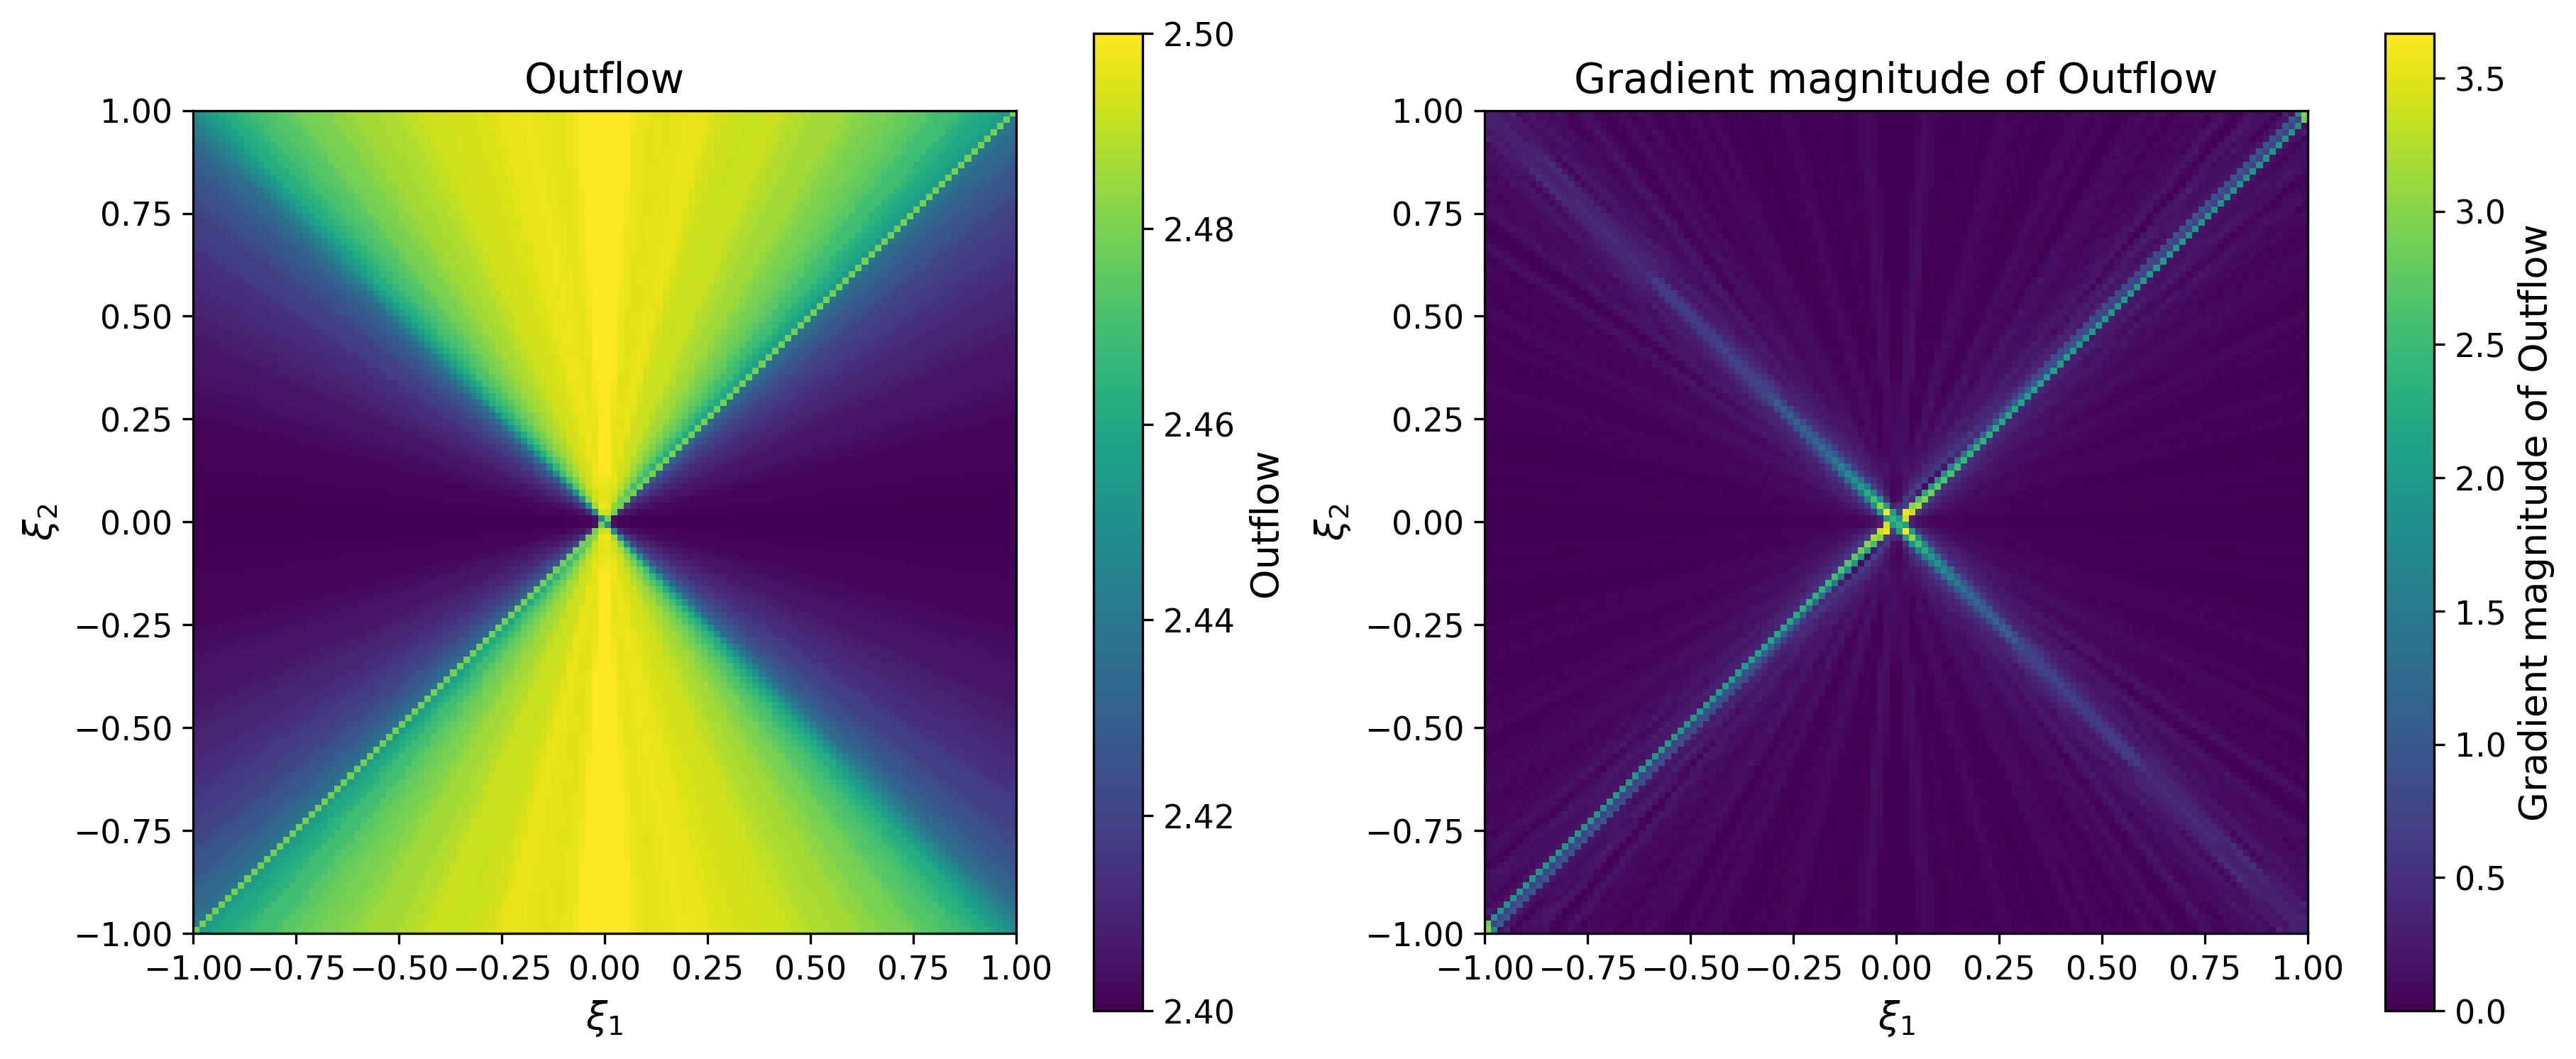

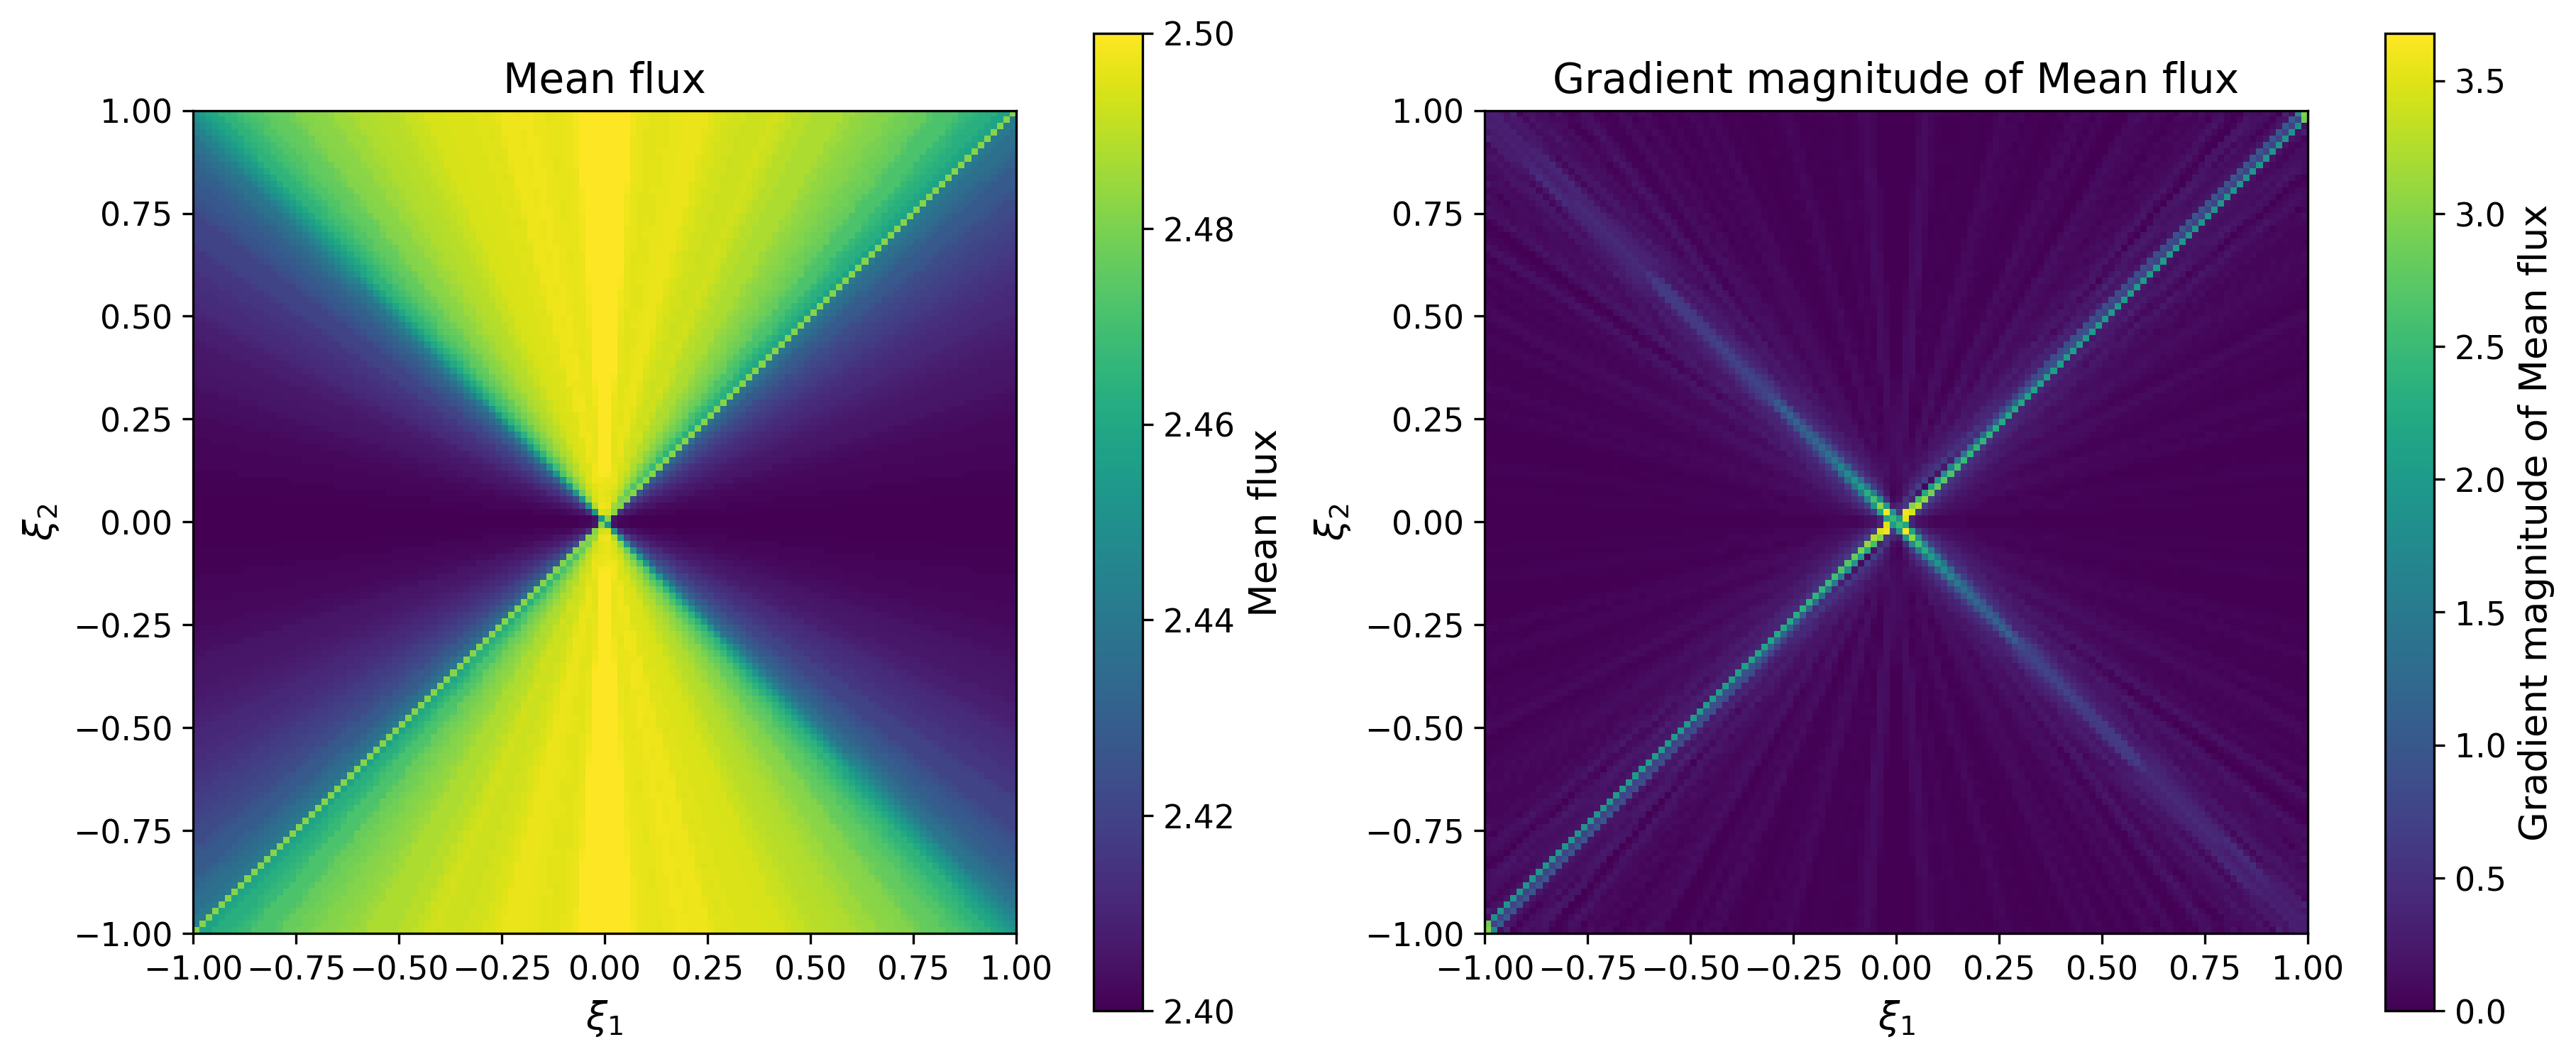

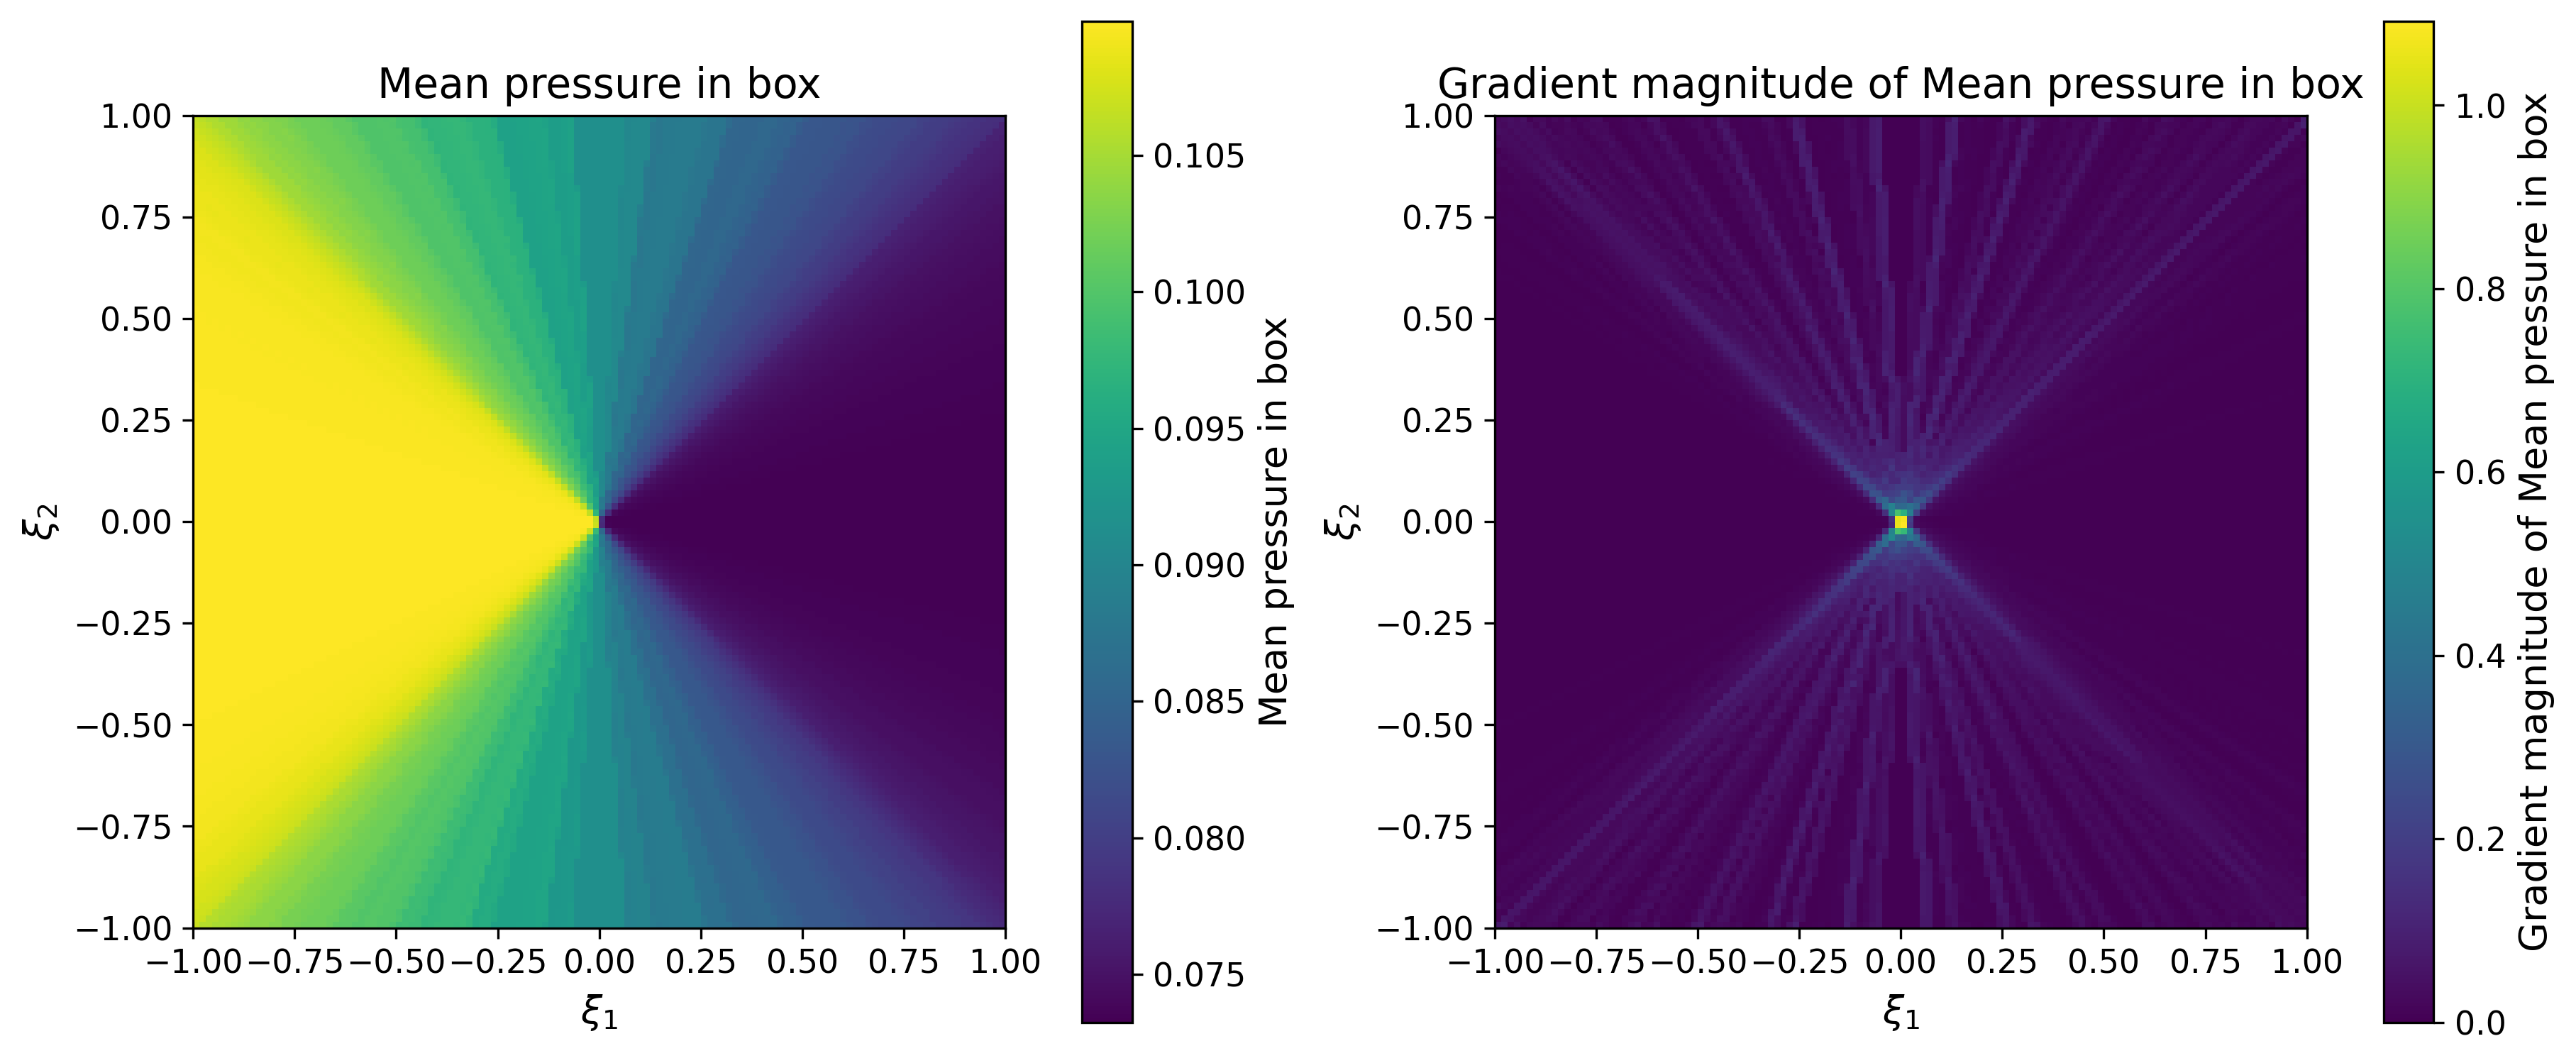

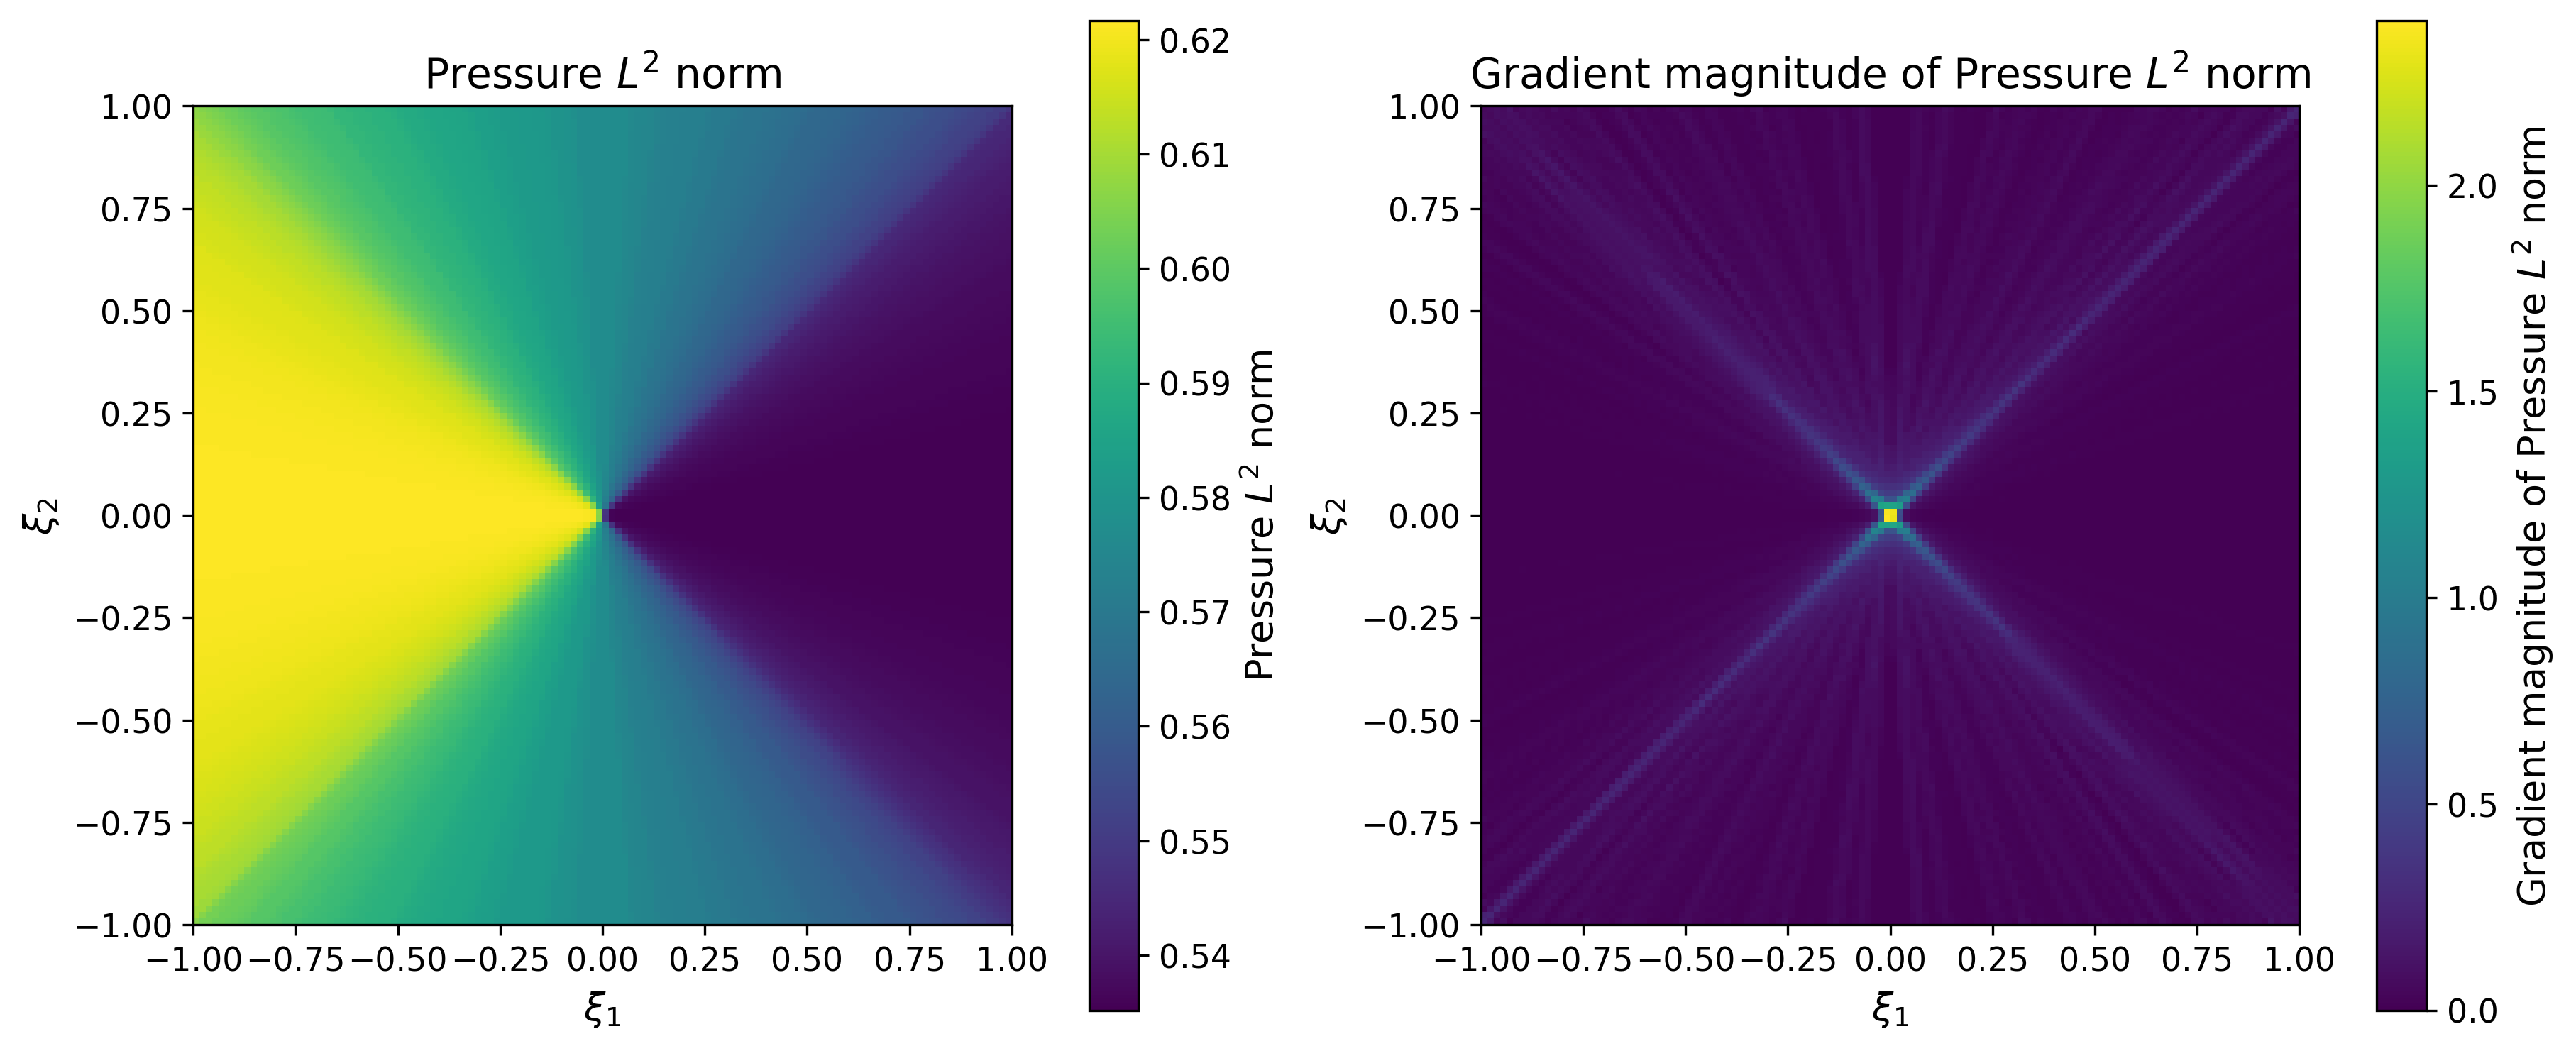

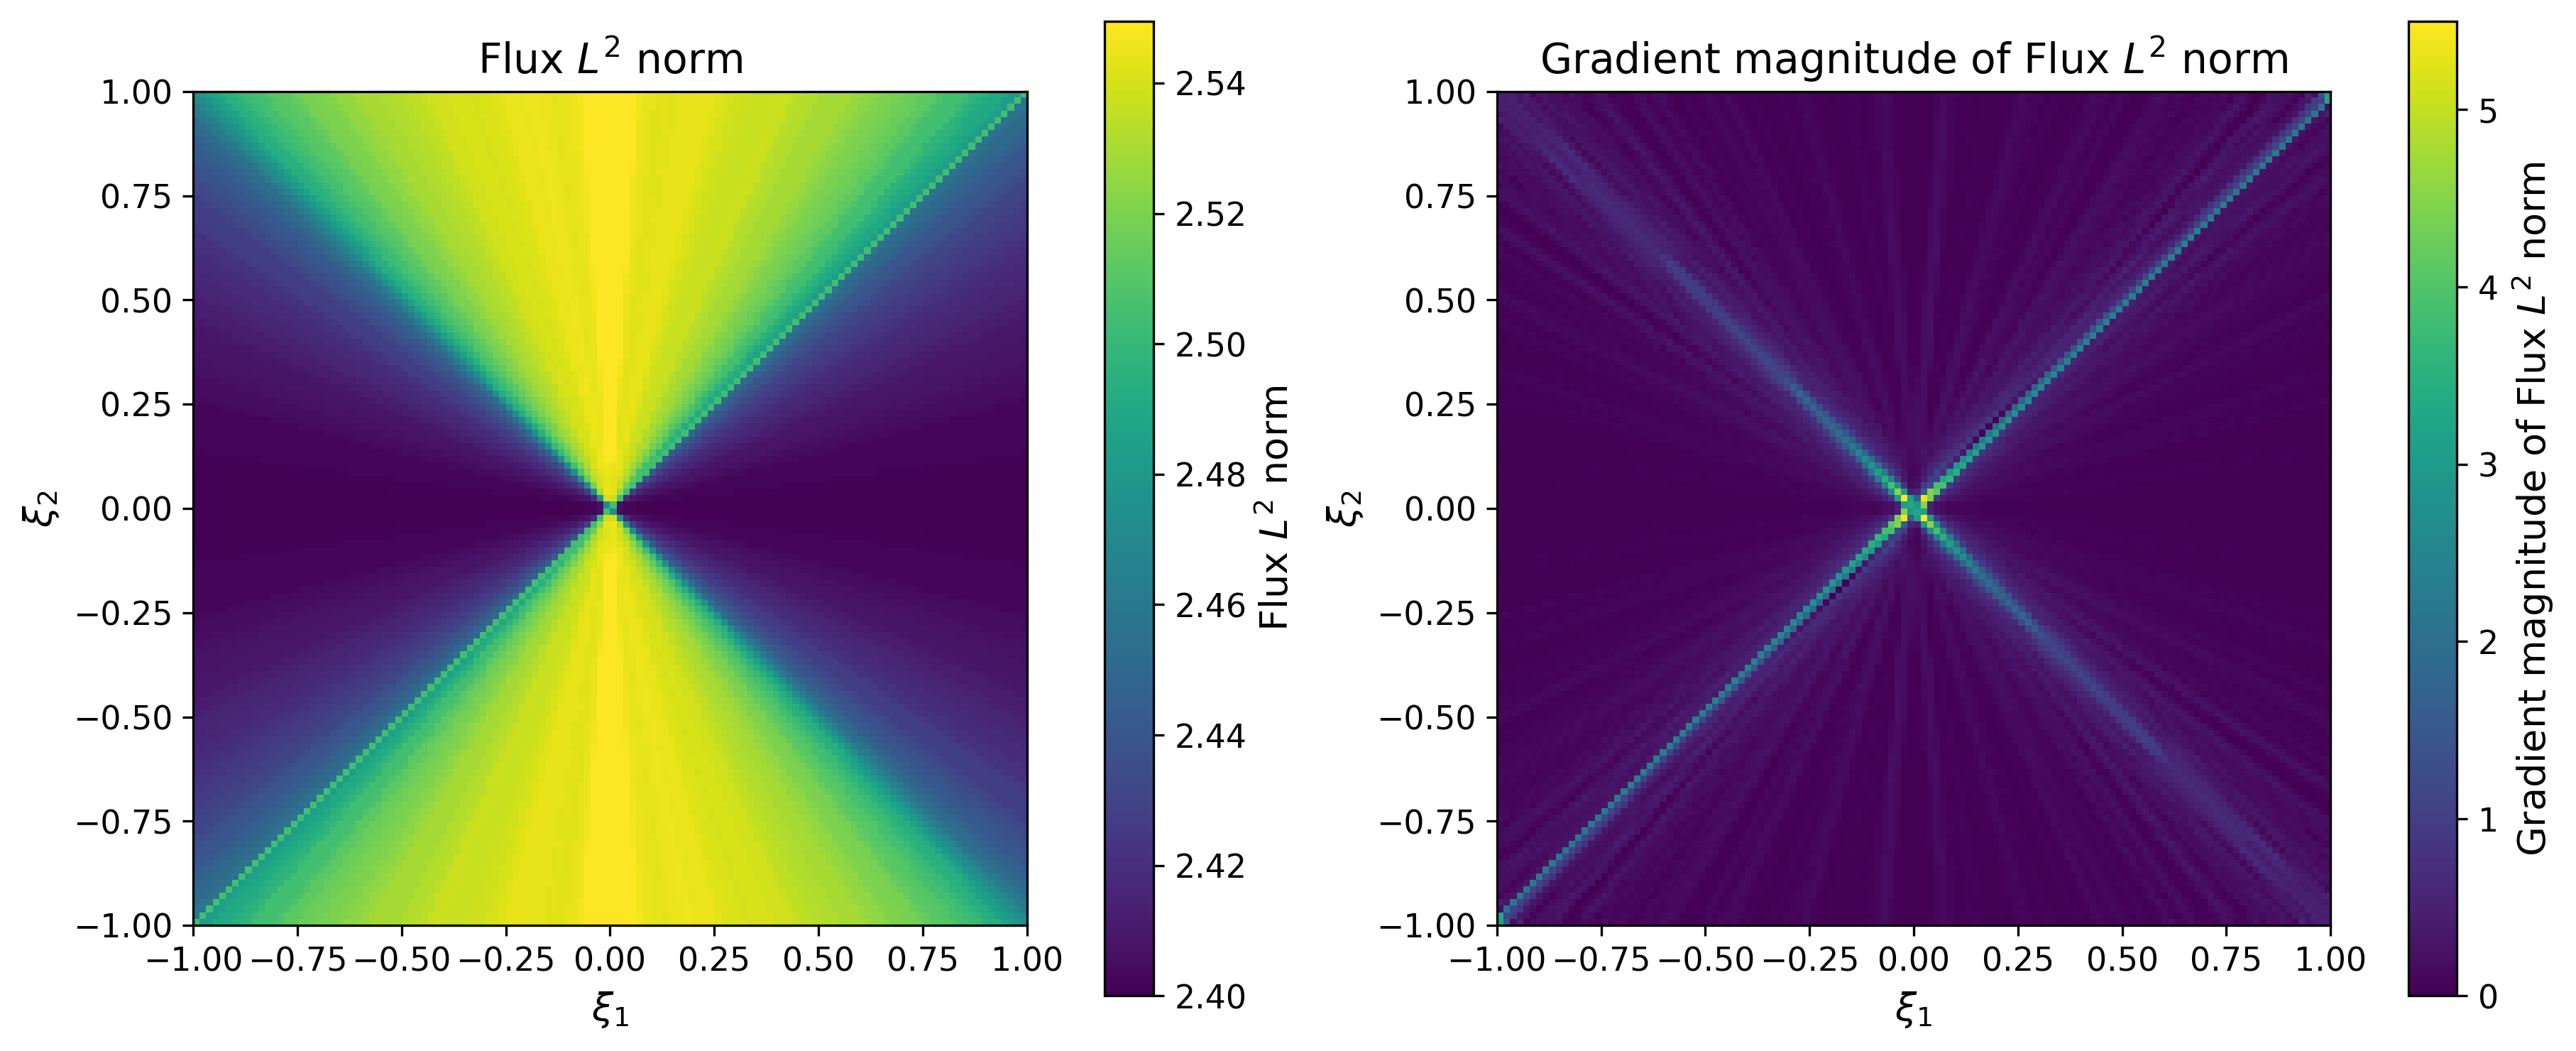

In [22]:
# --- Plot one figure per QoI ---
for k, (name, label) in enumerate(zip(qoi_names, qoi_labels)):
    values = qoi_values[k]

    d_values_dxi2, d_values_dxi1 = np.gradient(values, xi2, xi1)
    grad_values = np.hypot(d_values_dxi1, d_values_dxi2)

    fig, axes = plt.subplots(
        1,
        2,
        figsize=(12, 5),
        constrained_layout=True,
    )

    im0 = axes[0].imshow(
        values,
        origin="lower",
        extent=[-1, 1, -1, 1],
        aspect="equal",
        interpolation="nearest",
    )
    axes[0].set(
        xlabel=r"$\xi_1$",
        ylabel=r"$\xi_2$",
        title=label,
    )
    fig.colorbar(im0, ax=axes[0], label=label)

    im1 = axes[1].imshow(
        grad_values,
        origin="lower",
        extent=[-1, 1, -1, 1],
        aspect="equal",
        interpolation="nearest",
    )
    axes[1].set(
        xlabel=r"$\xi_1$",
        ylabel=r"$\xi_2$",
        title=rf"Gradient magnitude of {label}",
    )
    fig.colorbar(
        im1,
        ax=axes[1],
        label=rf"Gradient magnitude of {label}",
    )

    #fig.suptitle(name.replace("_", " ").title())
    plt.show()

In [20]:
import Tasmanian


# --- Select just the pressure L2 QoI ---
pressure_l2_index = qoi_names.index("pressure_L2")
pressure_l2_label = qoi_labels[pressure_l2_index]

# Reference field from the dense evaluation above
pressure_l2_values = qoi_values[pressure_l2_index]

# Its gradient magnitude, computed on the dense reference grid
dP_dxi2, dP_dxi1 = np.gradient(pressure_l2_values, xi2, xi1)
pressure_l2_grad = np.hypot(dP_dxi1, dP_dxi2)

# --- Tasmanian local adaptive sparse grid parameters ---
tolerance = 1.0e-4
initial_depth = 2
local_polynomial_order = 0
refinement_criterion = "fds"  # family-direction-selective refinement
max_refinement_steps = 10


def pressure_l2_model(tasmanian_points):

    points = np.array(tasmanian_points, dtype=float, copy=True)
    values = np.empty((len(points), 1))

    for m, xi in enumerate(points):
        field.setXi(xi)
        qoi = np.asarray(darcy.qoi(xi), dtype=float)
        values[m, 0] = qoi[pressure_l2_index]

    return values


# --- Construct the initial local-polynomial grid ---
grid = Tasmanian.makeLocalPolynomialGrid(
    iDimension=stochDim,
    iOutputs=1,
    iDepth=initial_depth,
    iOrder=local_polynomial_order,
    sRule="localp"#-boundary",
)


# --- Adaptive evaluation/refinement loop ---
for step in range(max_refinement_steps):
    needed_points = grid.getNeededPoints()

    if needed_points.shape[0] == 0:
        print("No additional refinement points requested; stopping.")
        break

    n_new = needed_points.shape[0]

    needed_values = pressure_l2_model(needed_points)
    grid.loadNeededPoints(needed_values)

    # Hierarchical coefficients are local-polynomial surpluses.
    # Restrict to the batch just loaded; old coarse-grid surpluses persist.
    surpluses = np.asarray(grid.getHierarchicalCoefficients()).reshape(-1, 1)
    max_new_surplus = np.max(np.abs(surpluses[-n_new:, 0]))

    print(
        f"Step {step:2d}: loaded {grid.getNumLoaded():4d} points; "
        f"max |new surplus| = {max_new_surplus:.3e}; "
        f"refining with tolerance = {tolerance:.1e}"
    )

    grid.setSurplusRefinement(
        fTolerance=tolerance,
        sCriteria=refinement_criterion,
        iOutput=0,
    )
else:
    print("Warning: reached max_refinement_steps before convergence.")

    

# All model-evaluation points retained by the final adaptive grid
adaptive_points = grid.getLoadedPoints()

print(f"Final number of adaptive samples: {adaptive_points.shape[0]}")

Step  0: loaded   21 points; max |new surplus| = 5.772e-01; refining with tolerance = 1.0e-04
Step  1: loaded   53 points; max |new surplus| = 4.448e-02; refining with tolerance = 1.0e-04
Step  2: loaded  169 points; max |new surplus| = 4.448e-02; refining with tolerance = 1.0e-04
Step  3: loaded  633 points; max |new surplus| = 4.448e-02; refining with tolerance = 1.0e-04


KeyboardInterrupt: 

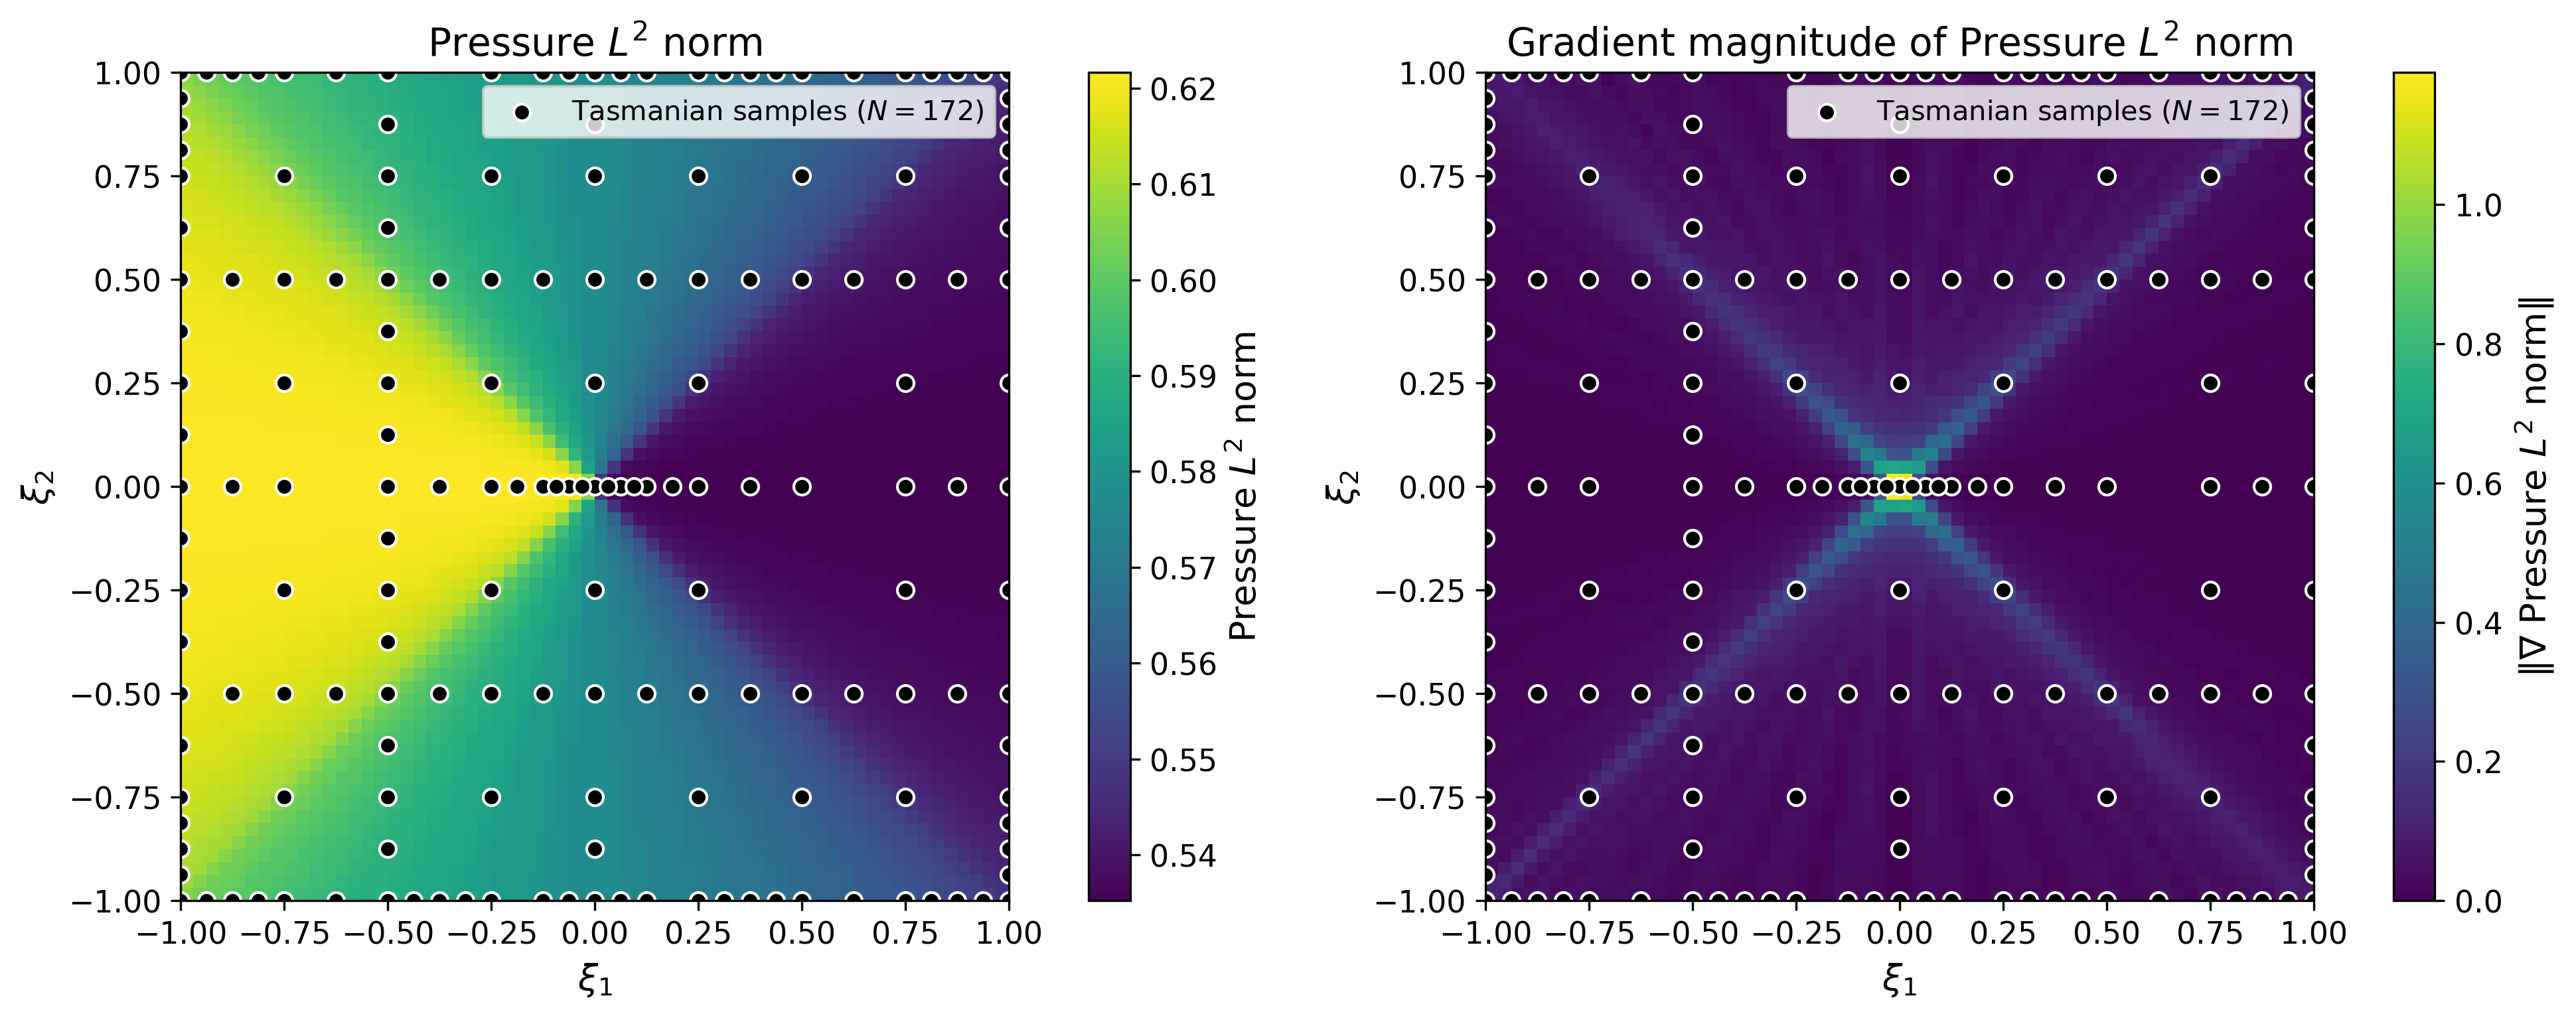

In [12]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(13, 5),
    constrained_layout=True,
)

for ax, data, title, colorbar_label in [
    (
        axes[0],
        pressure_l2_values,
        pressure_l2_label,
        pressure_l2_label,
    ),
    (
        axes[1],
        pressure_l2_grad,
        rf"Gradient magnitude of {pressure_l2_label}",
        rf"$\|\nabla$ {pressure_l2_label}$\|$",
    ),
]:
    image = ax.imshow(
        data,
        origin="lower",
        extent=[xi1.min(), xi1.max(), xi2.min(), xi2.max()],
        aspect="equal",
        interpolation="nearest",
    )

    ax.scatter(
        adaptive_points[:, 0],
        adaptive_points[:, 1],
        #s=28,
        facecolors="black",
        edgecolors="white",
        linewidths=1.0,
        label=rf"Tasmanian samples ($N={len(adaptive_points)}$)",
    )

    ax.set(
        xlabel=r"$\xi_1$",
        ylabel=r"$\xi_2$",
        title=title,
    )
    ax.legend(loc="upper right")
    fig.colorbar(image, ax=ax, label=colorbar_label)

plt.show()